# Target Auditing

In this notebook, we will perform and validate a search of target plants using computer vision. These tools will help an operator quickly tune the search parameters and manually clean up the results.

1. **Sample images**: we want to take representative sections of our region orthophoto to assess the efficacy of our search.
2. **Set parameters**: use the interactive widgets to set the CV search parameters.
3. **Verify results**: inspect the interactive map and add or delete target points.
4. **Export targets**: save the target location to a GeoJSON to be used for route planning.


We want to verify that the targets identified by our CV algorithm are correct and comprehensive.

In [37]:
import sys
import geopandas as gpd
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

In [38]:
region_crs = 32613 # Use this everywhere for consistency
visualization_crs = 4326 # Use this when we need leaflet visualizations

# region_image_path = '../input/IGNORE_Brewster-2024-all-orthophoto-UTM-32613.tif'
region_image_path = '../tile_server/input/IGNORE_reprojected_region.tif'

region_contour_geojson = '../input/interactive_proto/region_contour.geojson'
micro_routes_filename = '../input/interactive_proto/micro_routes.geojson'
targets_plants_filename = '../input/interactive_proto/targets.geojson'
depots_filename = '../input/interactive_proto/depot_points.geojson'


## 1. Sample Images

Take random and manual samples of region orthophoto. We want variety, to ensure that our search parameters are effective across varying environmental conditions. 

In [57]:
from ipyleaflet import (
    GeoData, GeoJSON, Map, Rectangle, TileLayer, 
    ScaleControl, GeomanDrawControl, LayersControl, WidgetControl
)
from ipywidgets import Button, IntSlider
import json
import pandas as pd
from shapely.geometry import shape
from shapely.ops import transform
from plant_search.verify_targets import get_image_sample_coordinates

def sample_region_map(region_image_path, region_geojson=None, container=None):
    """
    Create an interactive map and update the container with the combined GeoDataFrame.

    Parameters:
        region_image_path (str): Path to the orthophoto image.
        region_geojson (str): Path to the GeoJSON file defining the region.
        container (dict): A mutable container to hold the combined GeoDataFrame reference.

    Returns:
        Map: An ipyleaflet map instance.
    """   
    # Initialize data for interaction
    sample_size = 2048
    num_samples = 5
    sample_boxes_gdf = get_image_sample_coordinates(
        region_image_path, sample_size, num_samples, region_geojson
    )

    # Placeholder for combined GeoDataFrame
    if container is not None:
        container['combined_gdf'] = sample_boxes_gdf.copy()

    # Intitialize layers data
    with open(region_geojson, "r") as f:
        region_contour_data = json.load(f)
    region_geometry = shape(region_contour_data['features'][0]['geometry'])
    region_center = region_geometry.centroid

    # Initialize the map centered on the image
    m = Map(center=(region_center.y, region_center.x), 
            zoom=16, scroll_wheel_zoom=True,
            double_click_zoom=False,
            # crs=projections.EPSG4326,
        )

    # Add the region border to the map
    region_layer = GeoJSON(
        data=region_contour_data, 
        style={'color': 'blue', 'fill': False, 'fillOpacity': 0.05, 'weight': 2},
        name=region_contour_data['name'])
    m.add(region_layer)

    # Add orthophoto overlay
    tile_layer = TileLayer(
        url="http://localhost:8000/{z}/{x}/{y}.png",
        min_zoom=15,
        max_zoom=22,
        show_loading=True,
        max_requests_per_tile=5,  # Adjust as needed
        name="Region Image")
    m.add(tile_layer)


    # Add random image samples and widgets to adjust
    samples_layer = GeoData(geo_dataframe = sample_boxes_gdf,
                   style={'color': 'blue', 'weight':2, 'fillOpacity': 0.05 },
                   hover_style={'color': 'red' , 'opacity': 1.0, },
                   transform=True,
                   draggable=True,
                   pm_ignore=True,
                   name = 'Random Samples')
    m.add(samples_layer)

    # Widget: regenerate samples
    resample_button = Button(
        description="Resample Image",  # Button label
        tooltip="Get new random samples of region",  # Tooltip text
        icon="check"  # Optional icon (FontAwesome class, e.g., 'check', 'close')
    )
    def on_resample_click(change):
        sample_boxes_gdf = get_image_sample_coordinates(
            region_image_path, sample_size, num_samples, region_geojson
        )
        samples_layer.geo_dataframe = sample_boxes_gdf # refresh map layer

    resample_button.on_click(on_resample_click)
    m.add(WidgetControl(widget=resample_button, position='bottomright'))

    # Widget: Change number of samples
    samples_slider = IntSlider(
        value=num_samples, min=4, max=20, step=1,
        description="Count:",
        continuous_update=False  # Update only on release
    )
    def on_count_change(change):
        nonlocal num_samples # Ensure update of function variable

        new_sample_count = change['new']
        sample_boxes_gdf = get_image_sample_coordinates(
            region_image_path, sample_size, new_sample_count, region_geojson
        )
        num_samples = new_sample_count # Update function counter
        samples_layer.geo_dataframe = sample_boxes_gdf # refresh map layer

    samples_slider.observe(on_count_change, names='value')  # Trigger on value change
    m.add(WidgetControl(widget=samples_slider, position='bottomright'))


    # Save current samples
    save_button = Button(
        description="Save Samples",  # Button label
        tooltip="Save all samples for testing",  # Tooltip text
        icon="check"  # Optional icon (FontAwesome class, e.g., 'check', 'close')
    )
    def save_combined_features(change):
        nonlocal container

        # Ensure `draw_control.data` is iterable and extract features
        drawn_geometries = []
        if isinstance(draw_control.data, list):  # Check if data is a list
            for item in draw_control.data:
                if "geometry" in item:  # Ensure item contains geometry
                    drawn_geometries.append(shape(item["geometry"]))
        else:
            print("Draw control data is not iterable or does not contain valid features.")
            return

        # Convert the drawn geometries to a GeoDataFrame
        if drawn_geometries:
            drawn_gdf = gpd.GeoDataFrame(geometry=drawn_geometries, crs="EPSG:4326")
        else:
            drawn_gdf = gpd.GeoDataFrame(geometry=[], crs="EPSG:4326")

        # Combine the two GeoDataFrames
        programmatic_gdf = samples_layer.geo_dataframe # Get random rectangles
        combined_gdf = gpd.GeoDataFrame(pd.concat([drawn_gdf, programmatic_gdf], ignore_index=True))

        # Update the container
        if container is not None:
            container['combined_gdf'] = combined_gdf

        # # Save to GeoJSON
        # output_file = "combined_features.geojson"
        # combined_gdf.to_file(output_file, driver="GeoJSON")
        # print(f"Combined features saved to {output_file}.")
    save_button.on_click(save_combined_features)
    m.add(WidgetControl(widget=save_button, position='bottomright'))


    # Add conventional controls
    draw_control = GeomanDrawControl()
    draw_control.circlemarker = {}
    draw_control.polygon = {}
    draw_control.polyline = {}
    draw_control.rectangle = {
        "pathOptions": {
            "weight": 2,
            "color": "green",
            "fillOpacity": 0.1
        }
    }
    draw_control.rotate = False
    draw_control.cut = False
    draw_control.edit = False
    draw_control.drag = False # Does not maintain state 

    def handle_draw(self, action, geo_json):
        nonlocal container
        precision = 6 # Define precision for rounding

        def round_geometry(geometry, precision):
            """Round geometry coordinates to a specified precision."""
            return transform(lambda x, y: (round(x, precision), round(y, precision)), geometry)

        if action == "remove":
            # Extract the geometry of the deleted feature
            geo_json_geom = shape(geo_json[0]["geometry"])
            deleted_geometry = round_geometry(geo_json_geom, precision)
            
            # Remove matching features from the GeoDataFrame
            if container and "combined_gdf" in container:
                samples_layer.geo_dataframe = samples_layer.geo_dataframe[
                    ~samples_layer.geo_dataframe.geometry.apply(
                        lambda geom: round_geometry(geom, precision).equals(deleted_geometry)
                        )
                ]
                
        elif action == "drag":
            pass
        elif action == "create":
            pass
        else:
            print(f"Action: {action}")
            print(geo_json)

    draw_control.on_draw(handle_draw)
    m.add(draw_control)

    # m.add(FullScreenControl(position='topleft'))
    m.add(LayersControl(position='topright'))
    m.add(ScaleControl(position='bottomleft'))

    return m

In [58]:
combined_samples_container = {} # To retrieve edited samples from map

sample_map = sample_region_map(region_image_path, region_contour_geojson, combined_samples_container)
sample_map

Region polygon successfully loaded. Restricting samples to the polygon.


Map(center=[30.24893165719689, -103.6019209136208], controls=(ZoomControl(options=['position', 'zoom_in_text',…

## 2. Set Parameters
1. Visualize samples picked earlier
2. Visualize parameters on same sample set

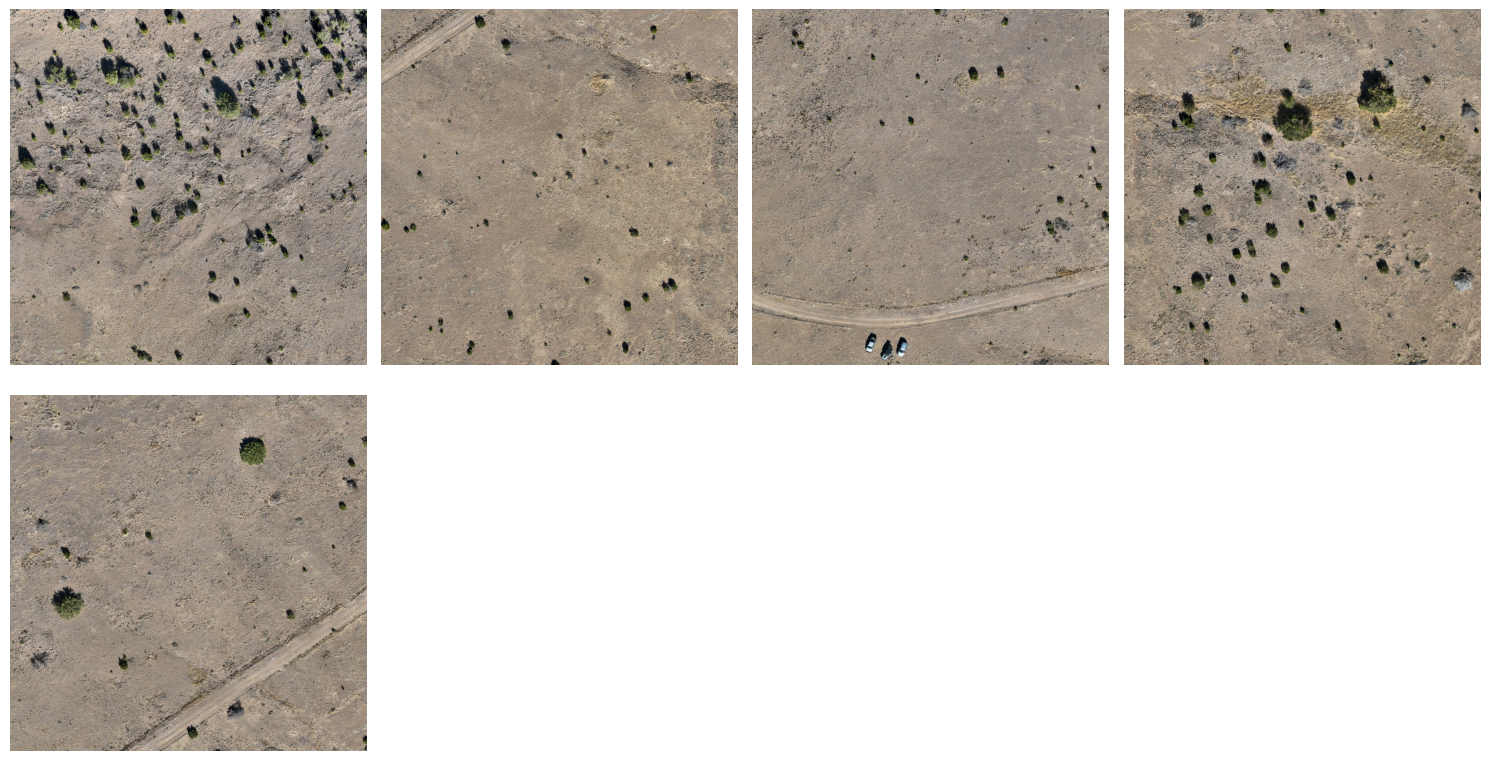

In [59]:
from plant_search.verify_targets import get_samples_from_gdf, plot_samples

# Extract and plot samples
samples_gdf = combined_samples_container['combined_gdf']
samples = get_samples_from_gdf(samples_gdf, region_image_path)
plot_samples(samples)


In [60]:
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
import numpy as np
from plant_search.vegetation_indices import calculate_all_rgb_indices

# Generate meaningful labels for the dropdown
image_labels = [f"Sample {i+1}" for i in range(len(samples))]
image_dict = dict(zip(image_labels, samples))  # Map labels to images

# Dropdown widget for selecting the image
image_dropdown = widgets.Dropdown(
    options=image_labels,
    value=image_labels[0],  # Default selected image
    description="Image:",
)

# Output widget for displaying plots
output = widgets.Output()

# Function to process the selected image and display all vegetation indices
def update_image(selected_image_label):
    with output:
        output.clear_output(wait=True)
        # Get the selected image
        selected_image = image_dict[selected_image_label]
        
        # Ensure the image is in HWC format (if it is CHW)
        if selected_image.ndim == 3 and selected_image.shape[0] == 3:
            selected_image = np.moveaxis(selected_image, 0, -1)

        # Calculate all vegetation indices
        indices = calculate_all_rgb_indices(selected_image)

        # Prepare the indices and titles for plotting
        index_titles = [
            ("Excess Green Index (ExG)", indices["ExG"]),
            ("Green Leaf Index (GLI)", indices["GLI"]),
            ("Normalized Difference Index (NDI)", indices["NDI"]),
            ("Visible Atmospherically Resistant Index (VARI)", indices["VARI"]),
            ("Triangular Vegetation Index (TVI)", indices["TVI"]),
        ]

        # Set up the grid for displaying all indices
        n_cols = 3
        n_rows = (len(index_titles) + n_cols - 1) // n_cols  # Compute rows
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 5))

        # Plot each vegetation index
        for i, (title, index) in enumerate(index_titles):
            row, col = divmod(i, n_cols)
            axes[row, col].imshow(index, cmap="Greens")
            axes[row, col].set_title(title, fontsize=14)
            axes[row, col].axis("off")

        # Turn off unused subplots
        for i in range(len(index_titles), n_rows * n_cols):
            row, col = divmod(i, n_cols)
            axes[row, col].axis("off")

        plt.tight_layout()
        plt.show()

# Callback for dropdown change
def on_image_change(change):
    update_image(change.new)

# Observe dropdown changes
image_dropdown.observe(on_image_change, names="value")

# Display the dropdown and output
display(widgets.VBox([image_dropdown, output]))

# Initialize with the first image
update_image(image_dropdown.value)


In [61]:
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
import numpy as np
from plant_search.vegetation_indices import (
    calculate_all_rgb_indices,
    normalize_rgb, calculate_exg, calculate_gli, calculate_ndi
)
from plant_search import vegetation_indices

# List of sample images
# samples = [image1, image2, image3]

# Vegetation index names
index_options = ["Excess Green Index (ExG)", 
                 "Green Leaf Index (GLI)", 
                 "Normalized Difference Index (NDI)", 
                 "Visible Atmospherically Resistant Index (VARI)", 
                 "Triangular Vegetation Index (TVI)"
                ]

# Dropdown for selecting the vegetation index
index_dropdown = widgets.Dropdown(
    options=index_options,
    value=index_options[0],  # Default selection
    description="Index:",
)

# Output widget for displaying plots
output = widgets.Output()

# Function to calculate a selected vegetation index for all samples and plot the results
def update_plot(selected_index):
    with output:
        output.clear_output(wait=True)
        
        # Prepare results for the selected vegetation index
        results = []
        for img in samples:
            # Ensure images are in HWC format
            if img.ndim == 3 and img.shape[0] == 3:
                img = np.moveaxis(img, 0, -1)

            r, g, b = vegetation_indices.normalize_rgb(img)

            if selected_index == "Excess Green Index (ExG)":
                indexed = vegetation_indices.calculate_exg(r, g, b)
            elif selected_index == "Green Leaf Index (GLI)":
                indexed = vegetation_indices.calculate_gli(r, g, b)
            elif selected_index == "Normalized Difference Index (NDI)":
                indexed = vegetation_indices.calculate_ndi(r, g)
            elif selected_index == "Visible Atmospherically Resistant Index (VARI)": 
                indexed = vegetation_indices.calculate_vari(r, g, b)
            elif selected_index == "Triangular Vegetation Index (TVI)":
                indexed = vegetation_indices.calculate_tvi(r, g, b)

            results.append(indexed)
        
        # Plot the results in a grid
        n_cols = 4  # Set number of columns
        n_rows = (len(samples) + n_cols - 1) // n_cols  # Calculate number of rows
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 5))

        for i, result in enumerate(results):
            row, col = divmod(i, n_cols)
            axes[row, col].imshow(result, cmap="Greens")
            axes[row, col].set_title(f"Sample {i+1}", fontsize=14)
            axes[row, col].axis("off")

        # Turn off unused subplots
        for i in range(len(results), n_rows * n_cols):
            row, col = divmod(i, n_cols)
            axes[row, col].axis("off")

        plt.tight_layout()
        plt.show()

# Callback function for dropdown
def on_index_change(change_value):
    update_plot(change_value.new)
index_dropdown.observe(on_index_change, names="value") # Observe dropdown changes

display(widgets.VBox([index_dropdown, output])) # Display the widgets
update_plot(index_dropdown.value) # Initialize with the first vegetation index


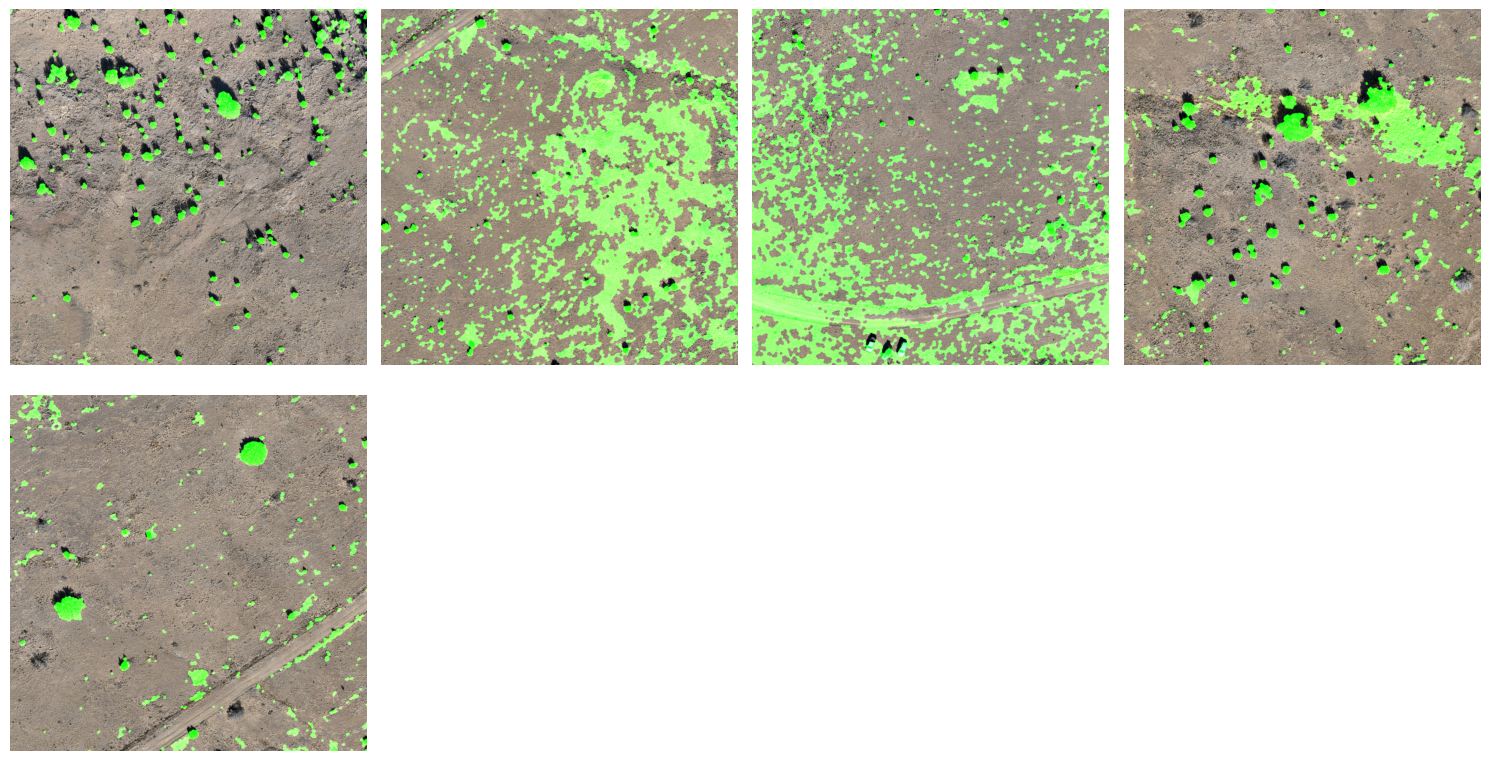

In [62]:
from plant_search.load_image import load_image
from plant_search.verify_targets import plot_samples
from plant_search.vegetation_indices import normalize_rgb, calculate_exg


from skimage.exposure import equalize_adapthist
from skimage.filters import threshold_otsu
from skimage.morphology import opening, closing, disk
import cv2


def perform_cv(image):

    exg = calculate_exg(*normalize_rgb(image))
    exg_normalized = (exg - np.min(exg)) / (np.max(exg) - np.min(exg))  # Normalize to [0, 1]
    exg_uint8 = (exg_normalized * 255).astype(np.uint8)

    bl_sigma_color = 50
    bl_sigma_spatial = 15 # Lower number is faster

    # Step 1: Bilateral Filtering using OpenCV
    bilateral_smoothed_exg = cv2.bilateralFilter(
        exg_uint8 , d=9, 
        sigmaColor=bl_sigma_color, 
        sigmaSpace=bl_sigma_spatial
    )
    bilateral_smoothed_exg = bilateral_smoothed_exg / 255.0  # Scale back to [0, 1]

    # Step 2: Contrast Enhancement with CLAHE
    clahe_exg = equalize_adapthist(bilateral_smoothed_exg, clip_limit=0.008)

    # Step 3: Morphological Operations (Opening → Closing)
    selem = disk(7)  # Structuring element
    morph_exg = closing(opening(clahe_exg, selem), selem)

    # Step 4: Thresholding (Otsu's method)
    otsu_threshold = threshold_otsu(morph_exg)
    binary_mask = morph_exg > otsu_threshold

    # return binary_mask

    highlighted_image = image.copy() * 255
    # Enhance the mask regions with green (or any desired enhancement)
    highlighted_image[binary_mask, 1] = 1.0  # Max out the green channel for mask regions
    return highlighted_image * 255


def plot_cv(samples):
    
    results = [perform_cv(sample) for sample in samples]
    # results = [perform_cv(samples[0])]
    plot_samples(results)


plot_cv(samples)

## 3. Audit Target Results

In [11]:
from ipyleaflet import (
    Map, GeoJSON, LayersControl, ScaleControl, 
    FullScreenControl, GeomanDrawControl,
    TileLayer, LocalTileLayer, GeoData,
)
from ipyleaflet.projections import projections
from ipywidgets import Layout

from shapely.geometry import shape
from shapely.wkt import loads
import json
import geopandas as gpd

from ipyleaflet.projections import projections

def plot_route_on_image(region_geojson, depots_filename, micro_routes_filename, targets_plants_filename):

    # Get image data
    # image, transform, bounds, image_crs = load_image(orthophoto_path)

    with open(region_geojson, "r") as f:
        region_contour_data = json.load(f)
    region_geometry = shape(region_contour_data['features'][0]['geometry'])
    region_center = region_geometry.centroid

    with open(depots_filename, "r") as f:
        depot_data = json.load(f)

    with open(micro_routes_filename, "r") as f:
        micro_routes_data = json.load(f)

    with open(targets_plants_filename, "r") as f:
        targets_data = json.load(f)
    
    
    
    bboxes_gdf = gpd.read_file(targets_plants_filename) # Read in from file
    bboxes_gdf['bounding_box'] = bboxes_gdf['bounding_box'].apply(loads) # str to Polygon
    bboxes_gdf.set_geometry('bounding_box', inplace=True) # It is the primary geometry
    bboxes_gdf = bboxes_gdf.drop(columns=['region_outline_version', 'geometry']) # remove confusing cols
    bboxes_gdf = bboxes_gdf.set_crs(region_crs).to_crs(visualization_crs) # Needs CRS, then convert

    
    # bounding_boxes_gdf = gpd.GeoDataFrame(bboxes_gdf, geometry='geometry', crs=bboxes_gdf.crs)
    # bounding_boxes_geojson = bounding_boxes_gdf.to_json()

    # Set up the map
    m = Map(center=(region_center.y, region_center.x),
            zoom=16, scroll_wheel_zoom=True,
            double_click_zoom=False,
            layout=Layout(height="700px"),  # Set desired dimensions
            # crs=projections.EPSG4326
        )

    # Add orthophoto overlay
    tile_layer = TileLayer(
        url="http://localhost:8000/{z}/{x}/{y}.png",
        min_zoom=15,
        max_zoom=22,
        show_loading=True,
        max_requests_per_tile=5,  # Adjust as needed
        name="Region Image")
    m.add_layer(tile_layer)

    # Add the region border to the map
    region_layer = GeoJSON(
        data=region_contour_data, 
        style={'color': 'blue', 'fillOpacity': 0.05, 'weight': 2},
        name=region_contour_data['name'])
    m.add(region_layer)

    depot_points = GeoJSON(
        data=depot_data,
        style={'color': 'black', 'radius':10, 'fillColor': '#3366cc', 'opacity':0.5, 'weight':1.9, 'dashArray':'2', 'fillOpacity':0.6},
        hover_style={'fillColor': 'red' , 'fillOpacity': 0.2},
        point_style={'radius': 3, 'color': 'red', 'fillOpacity': 0.8, 'fillColor': 'blue', 'weight': 3},
        draggable=True,
        name=depot_data['name']
    )
    m.add(depot_points)

    routes_layer = GeoJSON(
        data=micro_routes_data, 
        style={'color': 'green', 'fillColor': 'green', 'opacity': 0.75, 'weight': 4},
        hover_style={'color': 'red' , 'opacity': 0.8, 'weight': 3},
        name=f'Micro Routes'
    )
    # m.add(routes_layer)

    targets_layer = GeoJSON(
        data=targets_data,
        style={'color': 'black', 'radius':6, 'fillColor': 'red', 'opacity':0.5, 'weight':1, 'fillOpacity':0.6},
        hover_style={'fillColor': 'red' , 'fillOpacity': 0.2},
        point_style={'radius': 3, 'color': 'red', 'fillOpacity': 0.8, 'fillColor': 'blue', 'weight': 3},
        draggable=True,
        name=targets_data['name']
    )
    def on_click_target(event, feature, properties):
        # print(event)
        # print(feature)
        # print(properties)
        # print(len(targets_data['features']))
        targets_data['features'] = [
            feature for feature in targets_data['features']
            if feature['properties']['target_id'] != properties['target_id']
        ]
        print(len(targets_data['features']))
        targets_layer.data = targets_data

    targets_layer.on_click(on_click_target)


    m.add(targets_layer)

    bboxes_layer = GeoData(geo_dataframe = bboxes_gdf,
                   style={'color': 'red', 'opacity':0.5, 'weight':1.9,
                          'fill': False, 'fillColor': 'red', 'fillOpacity': 0.2
                          },
                   hover_style={'color': 'red' , 'opacity': 1.0, 'fill': False},
                   name = 'Countries')
    # m.add(bboxes_layer)

    draw_control = GeomanDrawControl()
    draw_control.circlemarker = {}
    draw_control.rotate = False
    # draw_control.cut = False
    draw_control.drag = False
    m.add(draw_control)

    # m.add(FullScreenControl(position='topleft'))
    m.add(LayersControl(position='topright'))
    m.add(ScaleControl(position='bottomleft'))
    return m

m = plot_route_on_image(region_contour_geojson, depots_filename, micro_routes_filename, targets_plants_filename)
m

Map(center=[30.24893165719689, -103.6019209136208], controls=(ZoomControl(options=['position', 'zoom_in_text',…

In [12]:
with open(targets_plants_filename, "r") as f:
    targets_data = json.load(f)
print(targets_data['features'])    

[{'type': 'Feature', 'properties': {'bounding_box': 'POLYGON ((634323.7010862518 3347384.218589365, 634329.556744471 3347384.218589365, 634329.556744471 3347379.7992743305, 634323.7010862518 3347379.7992743305, 634323.7010862518 3347384.218589365))', 'target_id': '4e07e911-a98a-4beb-b937-0fafc2480978', 'region_outline_version': '2024-12-14', 'region_name': 'Brewster_57'}, 'geometry': {'type': 'Point', 'coordinates': [-103.603803918554, 30.2506277518032]}}, {'type': 'Feature', 'properties': {'bounding_box': 'POLYGON ((634442.8029647457 3347383.0032777307, 634444.4049844472 3347383.0032777307, 634444.4049844472 3347381.732724658, 634442.8029647457 3347381.732724658, 634442.8029647457 3347383.0032777307))', 'target_id': 'af68ffec-713e-4f94-a758-5422ca6ddd4c', 'region_outline_version': '2024-12-14', 'region_name': 'Brewster_57'}, 'geometry': {'type': 'Point', 'coordinates': [-103.60259102142537, 30.250617799616144]}}, {'type': 'Feature', 'properties': {'bounding_box': 'POLYGON ((634345.135